# 01 — Data Cleaning, SQL & EDA
Our goal: Understand who churns, how much revenue is exposed, and which customer attributes are associated with churn.

In [3]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
ROOT=Path.cwd()
if not (ROOT/'data').exists(): ROOT=ROOT.parent
DATA=ROOT/'C:/Users/hp/OneDrive/Documents/New folder (2)/Telco-Customer-Churn.csv'
df=pd.read_csv(DATA)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df=df.dropna(subset=['TotalCharges']).copy()
df['ChurnFlag']=(df['Churn']=='Yes').astype(int)
df['ServicesCount']=(df[['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']].eq('Yes')).sum(axis=1)


## 1. Data quality checks

In [4]:
print(df.shape); display(df.head()); display(df.isna().sum().sort_values(ascending=False).head(10)); print(df.dtypes)

(7032, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,ServicesCount
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,1


customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
ChurnFlag             int64
ServicesCount         int64
dtype: object


## 2. Feature engineering

In [9]:
df['TenureBand']=pd.cut(df.tenure,[-1,6,12,24,48,72],labels=['0-6','7-12','13-24','25-48','49-72']); df['AvgMonthlyLifetimeValue']=df.TotalCharges/df.tenure.replace(0,np.nan); df.to_csv(ROOT/'C:/Users/hp/OneDrive/Documents/New folder (2)/telco_clean.csv',index=False); display(df[['tenure','TenureBand','MonthlyCharges','TotalCharges','ServicesCount']].head())

,tenure,TenureBand,MonthlyCharges,TotalCharges,ServicesCount
0,1,0-6,29.85,29.85,1
1,34,25-48,56.95,1889.50,3
2,2,0-6,53.85,108.15,3
3,45,25-48,42.30,1840.75,3
4,2,0-6,70.70,151.65,1


## 3. Core EDA

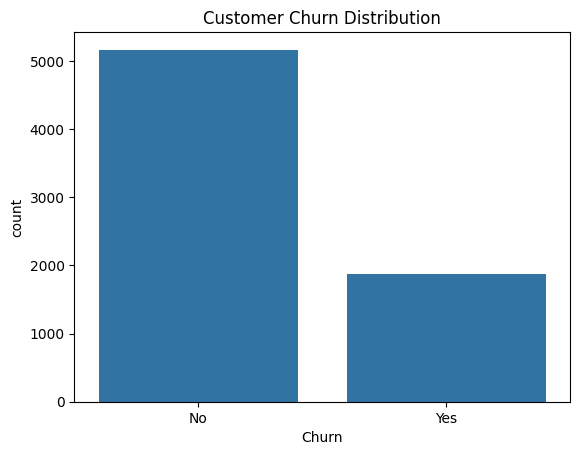

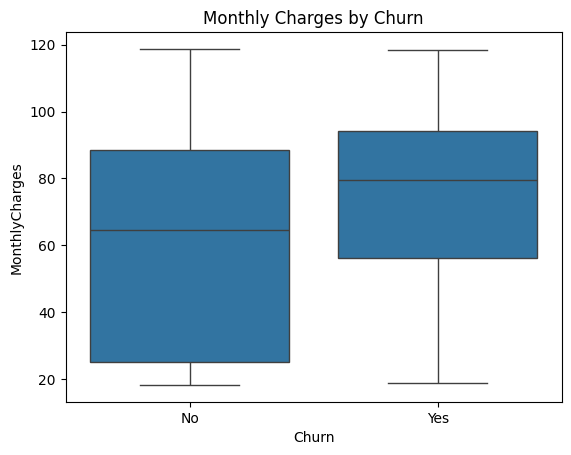

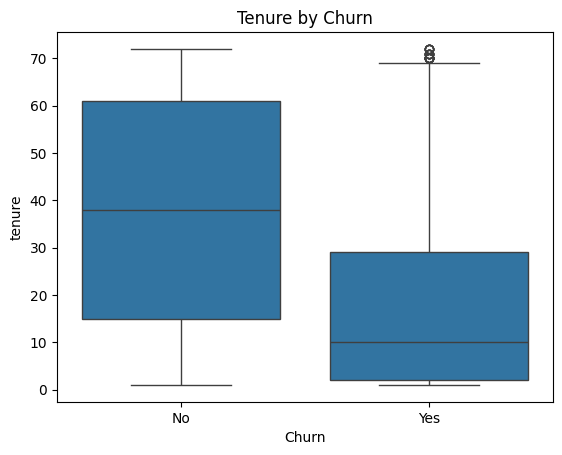

In [10]:
fig,ax=plt.subplots(); sns.countplot(data=df,x='Churn',ax=ax); ax.set_title('Customer Churn Distribution'); plt.show()
fig,ax=plt.subplots(); sns.boxplot(data=df,x='Churn',y='MonthlyCharges',ax=ax); ax.set_title('Monthly Charges by Churn'); plt.show()
fig,ax=plt.subplots(); sns.boxplot(data=df,x='Churn',y='tenure',ax=ax); ax.set_title('Tenure by Churn'); plt.show()

,churn_rate
Contract,
Month-to-month,0.427097
One year,0.112772
Two year,0.028487


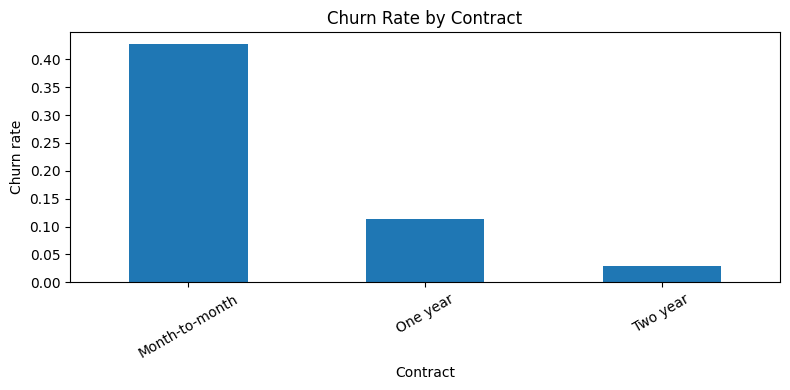

,churn_rate
InternetService,
Fiber optic,0.418928
DSL,0.189983
No,0.074342


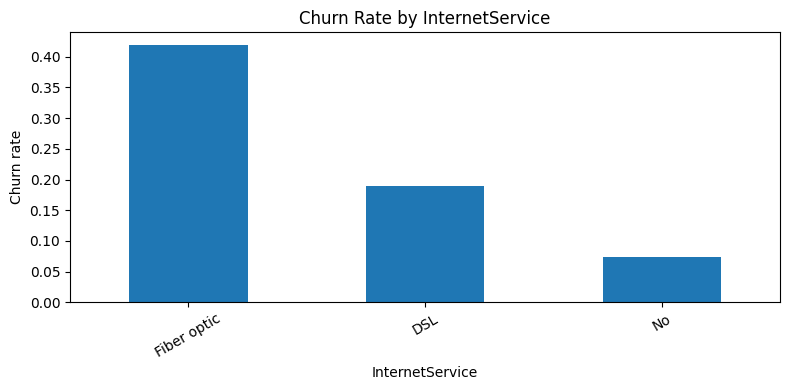

,churn_rate
PaymentMethod,
Electronic check,0.452854
Mailed check,0.192020
Bank transfer (automatic),0.167315
Credit card (automatic),0.152531


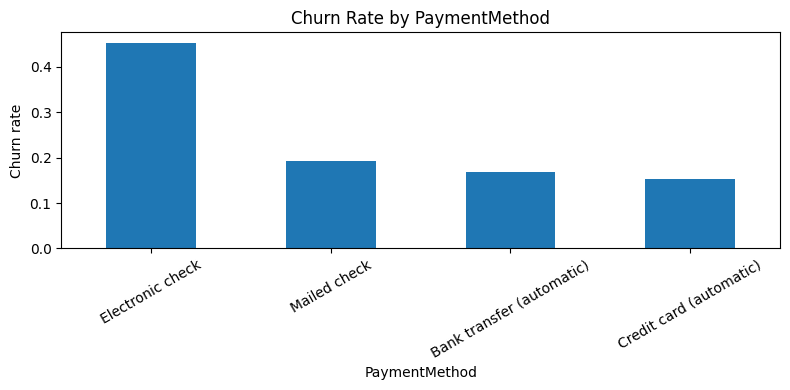

,churn_rate
TenureBand,
0-6,0.533333
7-12,0.358865
13-24,0.287109
25-48,0.203890
49-72,0.095132


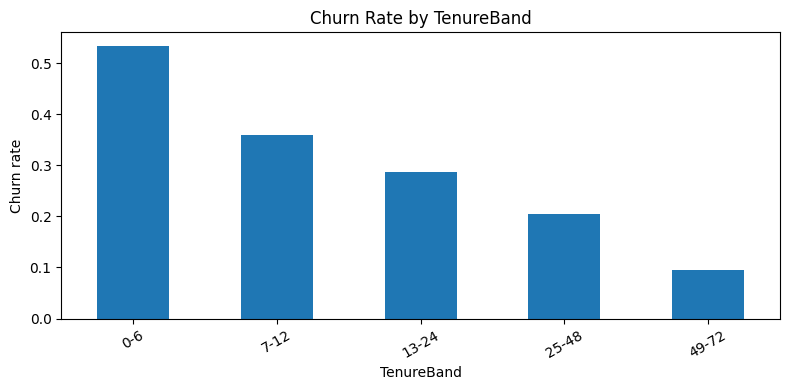

,churn_rate
TechSupport,
No,0.416475
Yes,0.151961
No internet service,0.074342


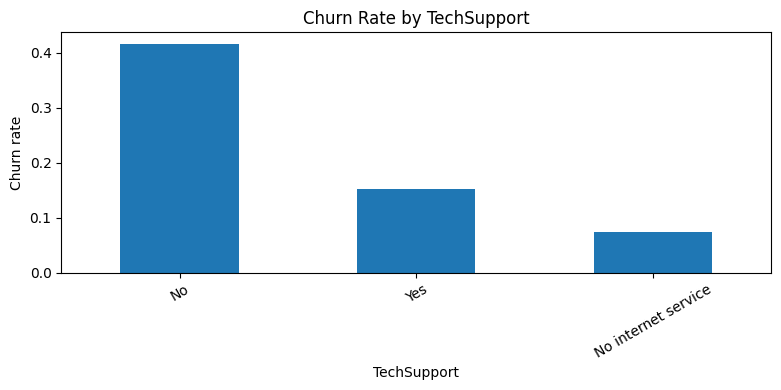

In [11]:
for col in ['Contract','InternetService','PaymentMethod','TenureBand','TechSupport']:
    rate=df.groupby(col,observed=False).ChurnFlag.mean().sort_values(ascending=False)
    display(rate.to_frame('churn_rate'))
    fig,ax=plt.subplots(figsize=(8,4)); rate.plot(kind='bar',ax=ax); ax.set_ylabel('Churn rate'); ax.set_title(f'Churn Rate by {col}'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## Interpretation
The raw IBM sample contains 7,043 rows and 21 columns; 11 records have blank TotalCharges and are excluded from numeric analyses after coercion. The observed churn rate in the usable analytical sample is calculated by the notebook, not hard-coded. 